# Spotify Track Analytics
**Prepared by:** Jasline Mwita  
**Dataset:** 114,000 Spotify tracks across 114 genres  
**Business question:** *What audio features predict a track's popularity — and what does this tell a record label about what to sign?*

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

RAW       = Path('../data/raw')
PROCESSED = Path('../data/processed')
PROCESSED.mkdir(exist_ok=True)

plt.rcParams['figure.dpi']    = 130
plt.rcParams['font.family']   = 'sans-serif'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

GREEN  = '#2d6a4f'
GREENL = '#52b788'
GREENS = ['#081c15','#1b4332','#2d6a4f','#40916c','#52b788','#74c69d','#95d5b2','#b7e4c7']

df = pd.read_csv(RAW / 'spotify_tracks.csv').drop(columns=['Unnamed: 0'], errors='ignore')
df = df.drop_duplicates(subset='track_id').reset_index(drop=True)

print(f'Tracks loaded: {len(df):,}')
print(f'Genres:        {df["track_genre"].nunique()}')
print(f'Artists:       {df["artists"].nunique():,}')
print(f'Popularity range: {df["popularity"].min()} – {df["popularity"].max()}')

Tracks loaded: 89,741
Genres:        113
Artists:       31,437
Popularity range: 0 – 100


---
## Part 1 — Popularity Distribution

> **Analyst note:** Popularity on Spotify is a 0–100 score updated daily based on total plays and recency. A score above 70 is considered a hit; below 20 is essentially undiscovered.

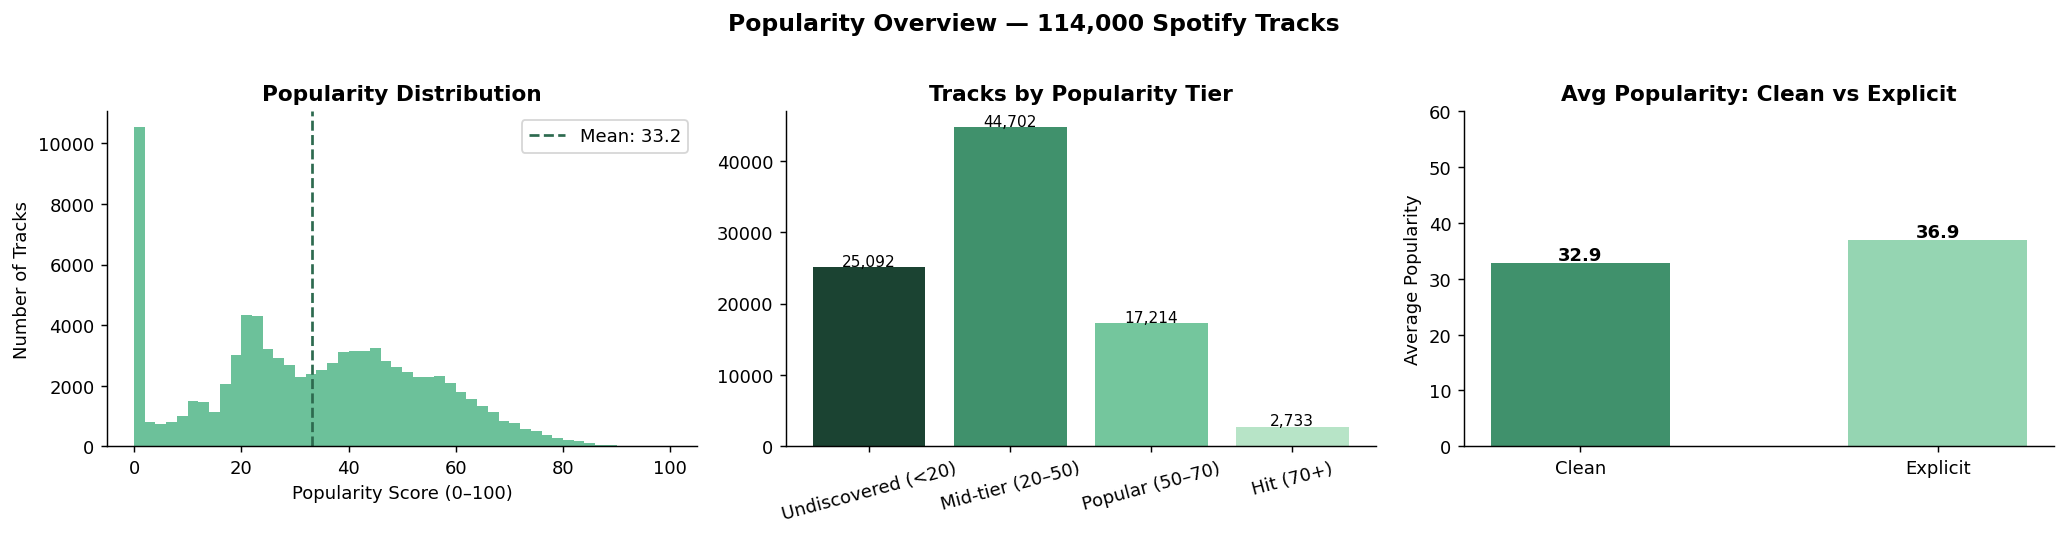

Hit tracks (popularity ≥70): 3,126 (3.5% of dataset)
Average popularity: 33.2
Explicit tracks are 4.0 points more popular on average


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(df['popularity'], bins=50, color=GREENL, edgecolor='none', alpha=0.85)
axes[0].axvline(df['popularity'].mean(), color=GREEN, linestyle='--', linewidth=1.5, label=f'Mean: {df["popularity"].mean():.1f}')
axes[0].set_title('Popularity Distribution', fontweight='bold')
axes[0].set_xlabel('Popularity Score (0–100)')
axes[0].set_ylabel('Number of Tracks')
axes[0].legend()

# Define hit tier
df['hit_tier'] = pd.cut(df['popularity'],
    bins=[-1, 20, 50, 70, 100],
    labels=['Undiscovered (<20)', 'Mid-tier (20–50)', 'Popular (50–70)', 'Hit (70+)']
)
tier_counts = df['hit_tier'].value_counts().sort_index()
colors_tier = [GREENS[1], GREENS[3], GREENS[5], GREENS[7]]
bars = axes[1].bar(tier_counts.index, tier_counts.values, color=colors_tier, edgecolor='none')
axes[1].set_title('Tracks by Popularity Tier', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, tier_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=8.5)

# Explicit vs not
expl = df.groupby('explicit')['popularity'].mean()
axes[2].bar(['Clean', 'Explicit'], expl.values, color=[GREENS[3], GREENS[6]], edgecolor='none', width=0.5)
axes[2].set_title('Avg Popularity: Clean vs Explicit', fontweight='bold')
axes[2].set_ylabel('Average Popularity')
axes[2].set_ylim(0, 60)
for i, v in enumerate(expl.values):
    axes[2].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

plt.suptitle('Popularity Overview — 114,000 Spotify Tracks', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PROCESSED / 'popularity_overview.png', bbox_inches='tight')
plt.show()

hits = df[df['popularity'] >= 70]
print(f'Hit tracks (popularity ≥70): {len(hits):,} ({len(hits)/len(df):.1%} of dataset)')
print(f'Average popularity: {df["popularity"].mean():.1f}')
print(f'Explicit tracks are {expl[True] - expl[False]:.1f} points more popular on average')

---
## Part 2 — Audio Feature Correlations with Popularity

Spotify measures 9 audio dimensions per track. This is the core of the analysis: **which dimensions actually move the popularity needle?**

| Feature | What it measures |
|---------|------------------|
| **danceability** | How suitable for dancing (rhythm, beat strength) |
| **energy** | Intensity and activity level |
| **valence** | Musical positivity (high = happy, low = sad) |
| **speechiness** | Presence of spoken words |
| **acousticness** | How acoustic vs electronic |
| **instrumentalness** | Likelihood of no vocals |
| **liveness** | Presence of live audience |
| **loudness** | Overall dB level |
| **tempo** | Beats per minute |

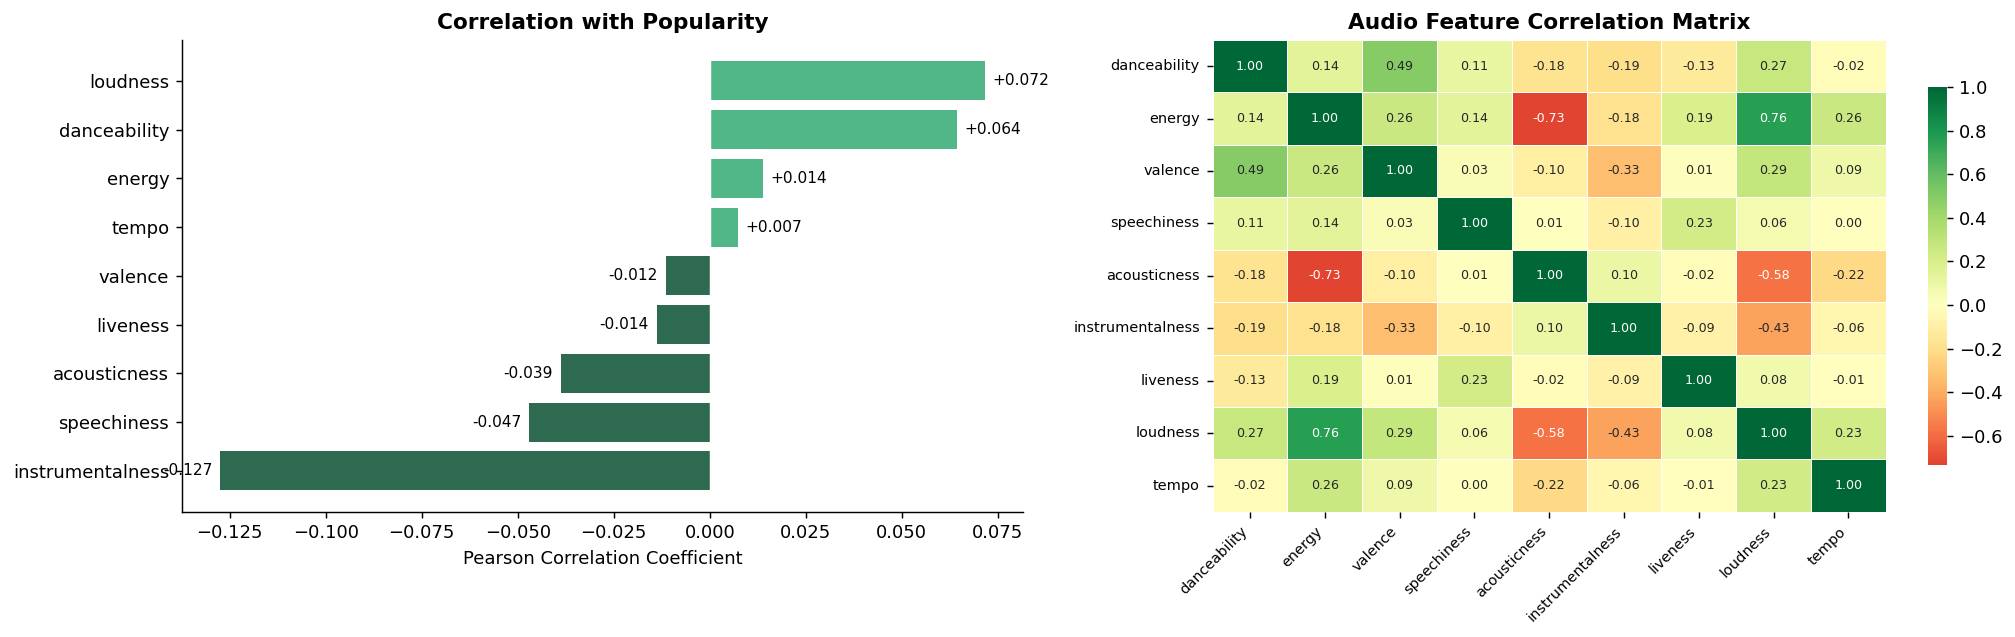

Top 3 positive correlations with popularity:
energy          0.013728
danceability    0.064281
loudness        0.071676

Top 3 negative correlations:
instrumentalness   -0.127465
speechiness        -0.047081
acousticness       -0.038847


In [3]:
audio_features = ['danceability','energy','valence','speechiness','acousticness',
                  'instrumentalness','liveness','loudness','tempo']

corr = df[audio_features + ['popularity']].corr()['popularity'].drop('popularity').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart of correlations
colors_corr = [GREEN if v < 0 else GREENL for v in corr.values]
bars = axes[0].barh(corr.index, corr.values, color=colors_corr, edgecolor='none')
axes[0].axvline(0, color='white', linewidth=0.8)
axes[0].set_title('Correlation with Popularity', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Pearson Correlation Coefficient')
for bar, val in zip(bars, corr.values):
    axes[0].text(val + (0.002 if val >= 0 else -0.002), bar.get_y() + bar.get_height()/2,
                 f'{val:+.3f}', va='center', fontsize=8.5,
                 ha='left' if val >= 0 else 'right')

# Heatmap of all audio features
corr_matrix = df[audio_features].corr()
sns.heatmap(corr_matrix, ax=axes[1], cmap='RdYlGn', center=0, annot=True,
            fmt='.2f', linewidths=0.5, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Audio Feature Correlation Matrix', fontweight='bold', fontsize=12)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(axes[1].get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig(PROCESSED / 'feature_correlations.png', bbox_inches='tight')
plt.show()

print('Top 3 positive correlations with popularity:')
print(corr.tail(3).to_string())
print('\nTop 3 negative correlations:')
print(corr.head(3).to_string())

---
## Part 3 — Genre Analysis

Which genres produce the most hits? And what does each genre *sound* like in terms of audio features?

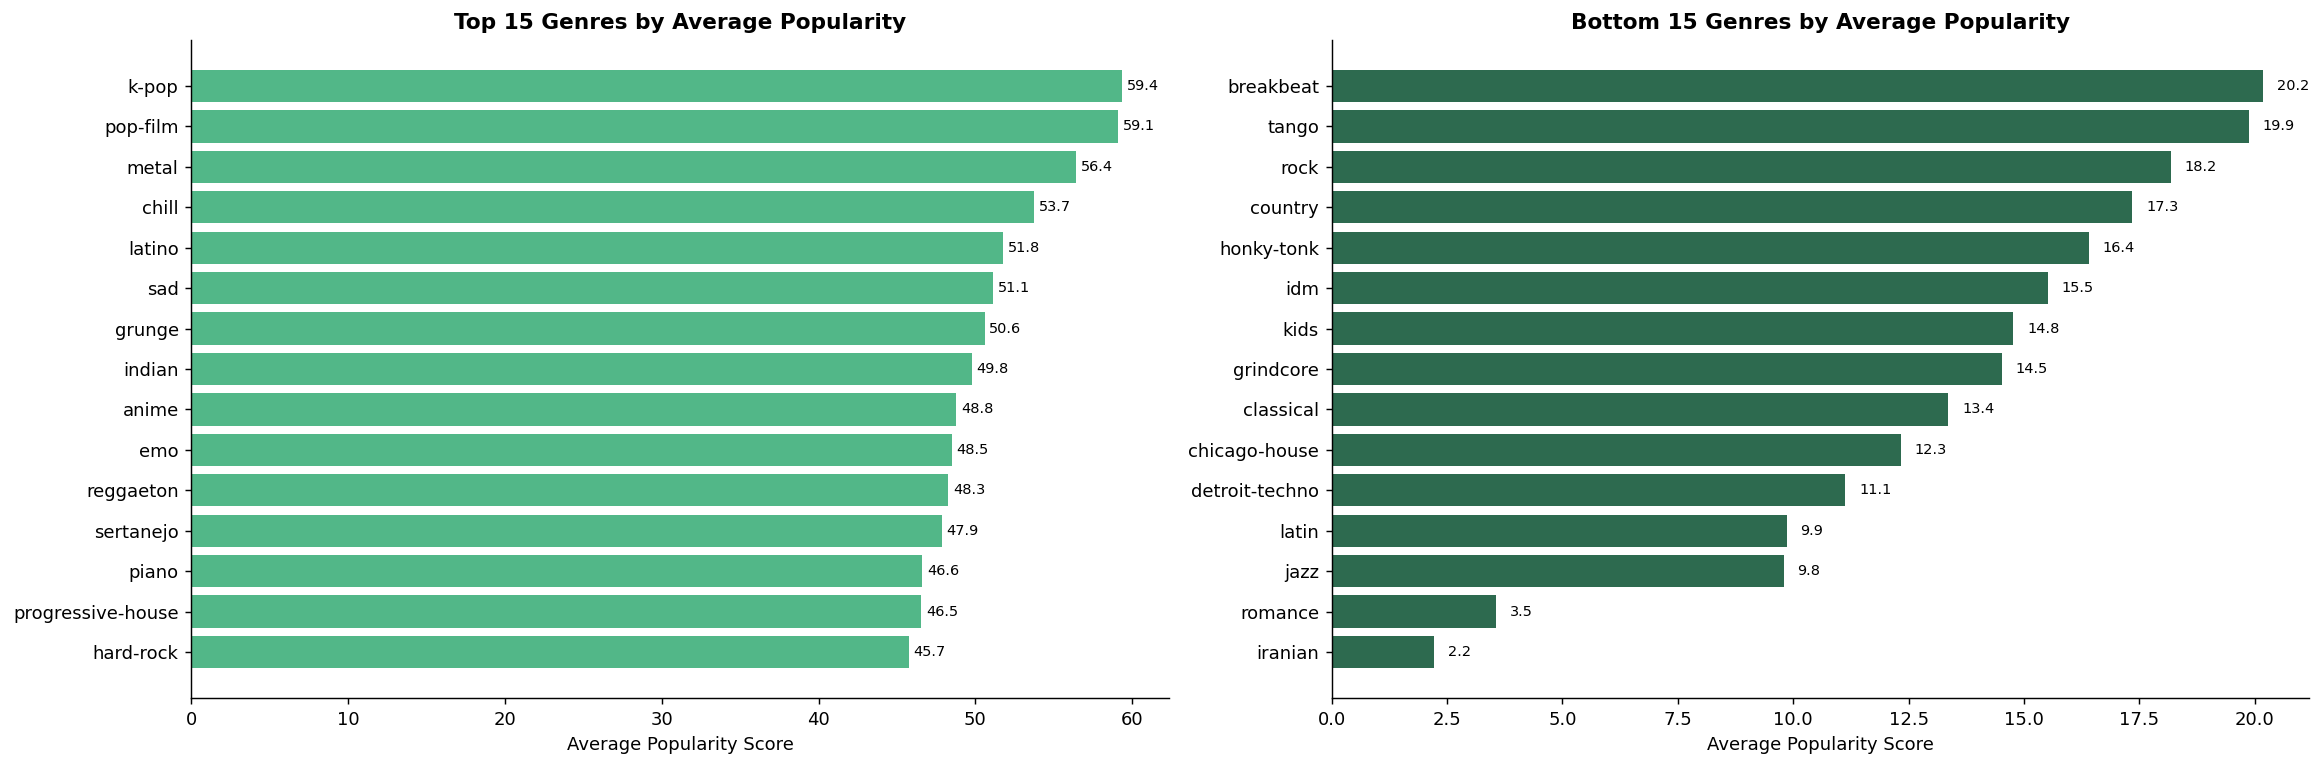

=== Top 10 Genres ===
             avg_popularity  hit_rate  avg_danceability  avg_energy  avg_valence
track_genre                                                                     
k-pop                59.359     0.232             0.642       0.683        0.569
pop-film             59.097     0.064             0.591       0.600        0.529
metal                56.422     0.207             0.481       0.841        0.425
chill                53.739     0.046             0.666       0.430        0.408
latino               51.789     0.352             0.755       0.712        0.622
sad                  51.110     0.028             0.702       0.479        0.440
grunge               50.587     0.050             0.455       0.805        0.401
indian               49.765     0.033             0.586       0.555        0.448
anime                48.777     0.024             0.538       0.674        0.435
emo                  48.500     0.080             0.601       0.668        0.441


In [4]:
# Top 15 genres by avg popularity
genre_stats = df.groupby('track_genre').agg(
    avg_popularity=('popularity','mean'),
    track_count=('track_id','count'),
    hit_rate=('popularity', lambda x: (x >= 70).mean()),
    avg_danceability=('danceability','mean'),
    avg_energy=('energy','mean'),
    avg_valence=('valence','mean')
).round(3).sort_values('avg_popularity', ascending=False)

top15 = genre_stats.head(15)
bottom15 = genre_stats.tail(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top genres
bars_t = axes[0].barh(top15.index[::-1], top15['avg_popularity'][::-1],
                      color=GREENL, edgecolor='none')
axes[0].set_title('Top 15 Genres by Average Popularity', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Average Popularity Score')
for bar, val in zip(bars_t, top15['avg_popularity'][::-1]):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=8)

# Bottom genres  
bars_b = axes[1].barh(bottom15.index[::-1], bottom15['avg_popularity'][::-1],
                      color=GREENS[2], edgecolor='none')
axes[1].set_title('Bottom 15 Genres by Average Popularity', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Average Popularity Score')
for bar, val in zip(bars_b, bottom15['avg_popularity'][::-1]):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(PROCESSED / 'genre_popularity.png', bbox_inches='tight')
plt.show()

print('=== Top 10 Genres ===')
print(genre_stats[['avg_popularity','hit_rate','avg_danceability','avg_energy','avg_valence']].head(10).to_string())

---
## Part 4 — The Mood Map

**Valence vs Energy** is the most intuitive visualisation in music analytics. It creates four emotional quadrants:

| Quadrant | Mood | Examples |
|----------|------|----------|
| High energy, high valence | Happy / Euphoric | Dance pop, party anthems |
| High energy, low valence | Angry / Intense | Metal, aggressive rap |
| Low energy, high valence | Peaceful / Content | Acoustic, chill |
| Low energy, low valence | Sad / Dark | Sad ballads, dark ambient |

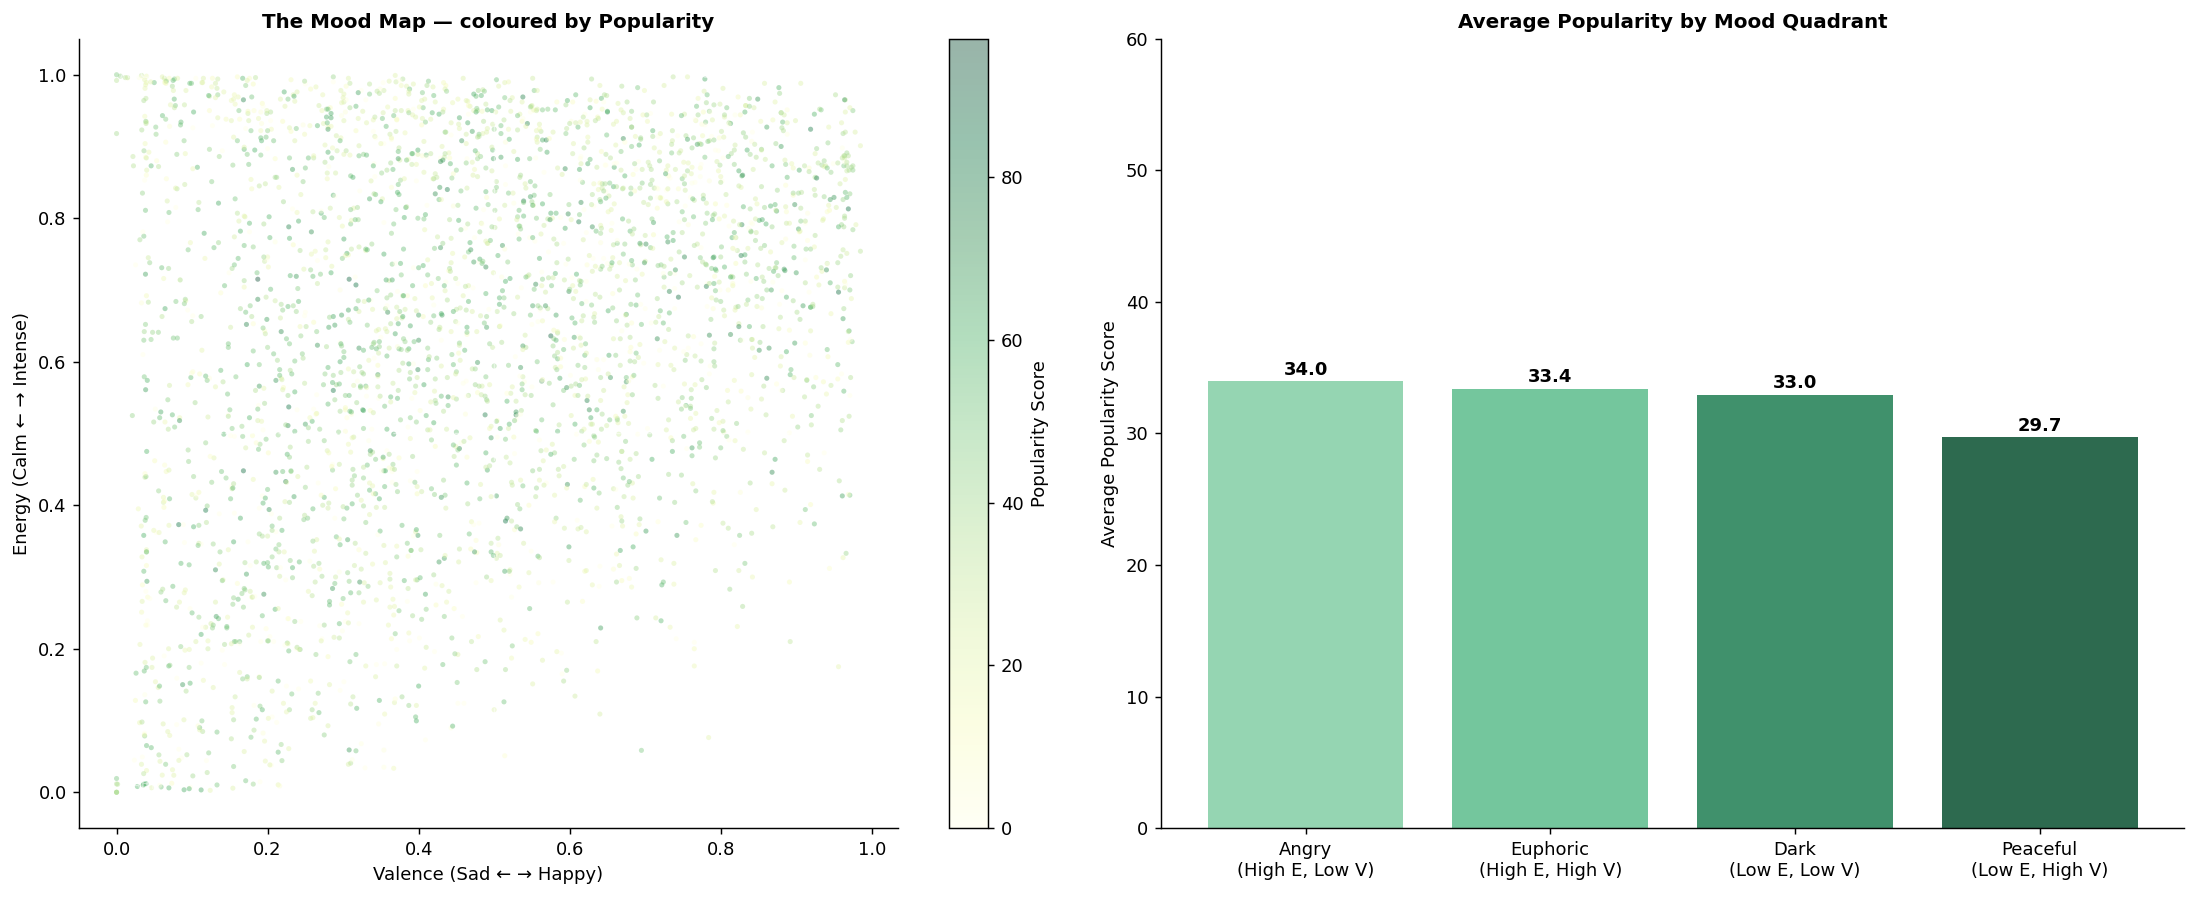

In [5]:
# Sample for readability
sample = df.sample(3000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Left: scatter coloured by popularity
sc = axes[0].scatter(sample['valence'], sample['energy'],
                     c=sample['popularity'], cmap='YlGn',
                     alpha=0.4, s=8, linewidths=0)
plt.colorbar(sc, ax=axes[0], label='Popularity Score')
axes[0].axhline(0.5, color='white', linewidth=0.8, alpha=0.5, linestyle='--')
axes[0].axvline(0.5, color='white', linewidth=0.8, alpha=0.5, linestyle='--')
axes[0].set_xlabel('Valence (Sad ← → Happy)', fontsize=10)
axes[0].set_ylabel('Energy (Calm ← → Intense)', fontsize=10)
axes[0].set_title('The Mood Map — coloured by Popularity', fontweight='bold', fontsize=11)
# Quadrant labels
axes[0].text(0.05, 0.95, 'ANGRY', transform=axes[0].transAxes, fontsize=8, color='white', alpha=0.5)
axes[0].text(0.75, 0.95, 'EUPHORIC', transform=axes[0].transAxes, fontsize=8, color='white', alpha=0.5)
axes[0].text(0.05, 0.05, 'DARK', transform=axes[0].transAxes, fontsize=8, color='white', alpha=0.5)
axes[0].text(0.75, 0.05, 'PEACEFUL', transform=axes[0].transAxes, fontsize=8, color='white', alpha=0.5)

# Right: avg popularity per quadrant
df['mood_quadrant'] = df.apply(lambda r:
    'Euphoric\n(High E, High V)'   if r['energy'] >= 0.5 and r['valence'] >= 0.5 else
    'Angry\n(High E, Low V)'       if r['energy'] >= 0.5 and r['valence'] < 0.5  else
    'Peaceful\n(Low E, High V)'    if r['energy'] < 0.5  and r['valence'] >= 0.5 else
    'Dark\n(Low E, Low V)', axis=1
)
quad_pop = df.groupby('mood_quadrant')['popularity'].mean().sort_values(ascending=False)
bars_q = axes[1].bar(quad_pop.index, quad_pop.values,
                     color=[GREENS[6], GREENS[5], GREENS[3], GREENS[2]], edgecolor='none')
axes[1].set_title('Average Popularity by Mood Quadrant', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Average Popularity Score')
axes[1].set_ylim(0, 60)
for bar, val in zip(bars_q, quad_pop.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.1f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(PROCESSED / 'mood_map.png', bbox_inches='tight')
plt.show()

---
## Part 5 — Hit Prediction Model

**Target:** Is a track a hit? (popularity ≥ 70)  
**Features:** All 9 audio features + duration + explicit flag + genre  
**Models compared:** Logistic Regression vs Random Forest vs Gradient Boosting  

> **Business application:** A&R teams at record labels could use this model to score unsigned demo tracks before deciding whether to sign an artist.

In [6]:
from sklearn.utils import resample

df['is_hit'] = (df['popularity'] >= 70).astype(int)

le = LabelEncoder()
df['genre_enc']    = le.fit_transform(df['track_genre'])
df['duration_min'] = df['duration_ms'] / 60000

feature_cols = ['danceability','energy','valence','speechiness','acousticness',
                'instrumentalness','liveness','loudness','tempo',
                'duration_min','explicit','genre_enc']

model_df = df[feature_cols + ['is_hit']].dropna()

# Downsample majority class — faster and avoids memory issues
hits_df  = model_df[model_df['is_hit'] == 1]
nhits_df = model_df[model_df['is_hit'] == 0].sample(len(hits_df), random_state=42)
balanced = pd.concat([hits_df, nhits_df]).sample(frac=1, random_state=42)

print(f'Balanced dataset: {len(balanced):,} rows ({len(hits_df):,} hits + {len(nhits_df):,} non-hits)')

X = balanced[feature_cols].astype(float)
y = balanced['is_hit']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

models = {
    'Logistic Regression': (LogisticRegression(max_iter=500, random_state=42), True),
    'Random Forest':       (RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1), False),
}

results = {}
for name, (model, use_scaled) in models.items():
    X_tr = X_train_s if use_scaled else X_train
    X_te = X_test_s  if use_scaled else X_test
    model.fit(X_tr, y_train)
    proba = model.predict_proba(X_te)[:, 1]
    auc   = roc_auc_score(y_test, proba)
    results[name] = {'auc': auc, 'model': model}
    print(f'{name}: AUC = {auc:.3f}')

best_name = max(results, key=lambda k: results[k]['auc'])
print(f'\n>>> Best model: {best_name} (AUC {results[best_name]["auc"]:.3f})')

Balanced dataset: 6,252 rows (3,126 hits + 3,126 non-hits)
Logistic Regression: AUC = 0.730


Random Forest: AUC = 0.783

>>> Best model: Random Forest (AUC 0.783)


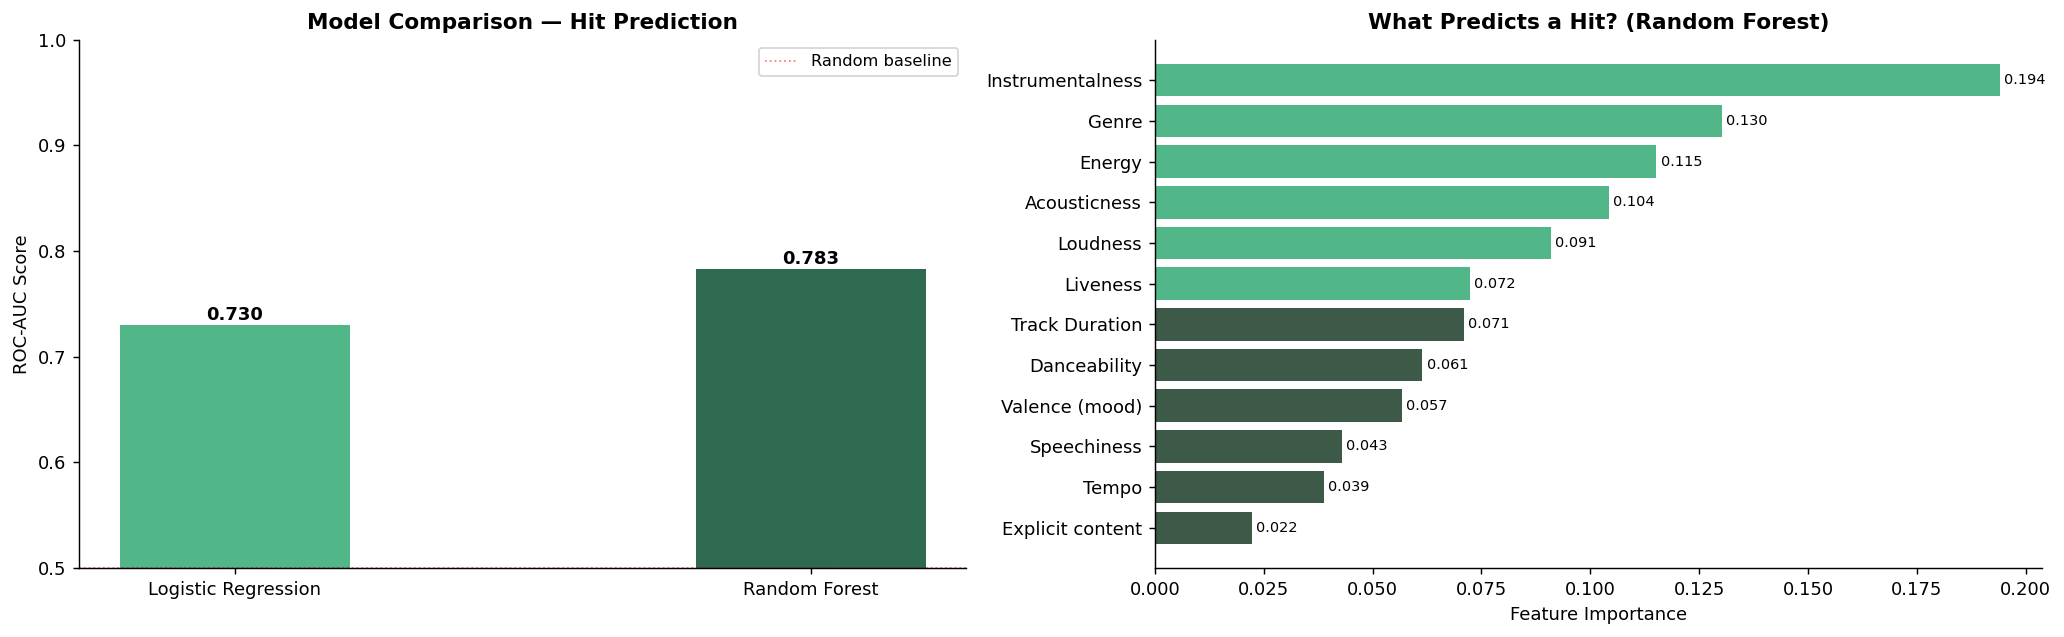

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Model AUC comparison
names = list(results.keys())
aucs  = [results[n]['auc'] for n in names]
bars1 = axes[0].bar(names, aucs, color=[GREENL, GREEN], edgecolor='none', width=0.4)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_ylabel('ROC-AUC Score')
axes[0].set_title('Model Comparison — Hit Prediction', fontweight='bold')
axes[0].axhline(0.5, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Random baseline')
axes[0].legend(fontsize=9)
for bar, val in zip(bars1, aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# Feature importance from Random Forest
rf_model = results['Random Forest']['model']
feat_imp = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()
label_map = {
    'danceability':'Danceability', 'energy':'Energy', 'valence':'Valence (mood)',
    'speechiness':'Speechiness',   'acousticness':'Acousticness',
    'instrumentalness':'Instrumentalness', 'liveness':'Liveness',
    'loudness':'Loudness', 'tempo':'Tempo', 'duration_min':'Track Duration',
    'explicit':'Explicit content', 'genre_enc':'Genre'
}
feat_imp.index = [label_map.get(i, i) for i in feat_imp.index]
bar_colors = [GREENL if v >= feat_imp.median() else '#3d5a48' for v in feat_imp.values]
axes[1].barh(feat_imp.index, feat_imp.values, color=bar_colors, edgecolor='none')
axes[1].set_title('What Predicts a Hit? (Random Forest)', fontweight='bold')
axes[1].set_xlabel('Feature Importance')
for i, v in enumerate(feat_imp.values):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(PROCESSED / 'hit_prediction_model.png', bbox_inches='tight')
plt.show()

---
## Part 6 — Song Clustering (Unsupervised)

Using K-Means to group songs into natural clusters based purely on their audio DNA — no genre labels used.

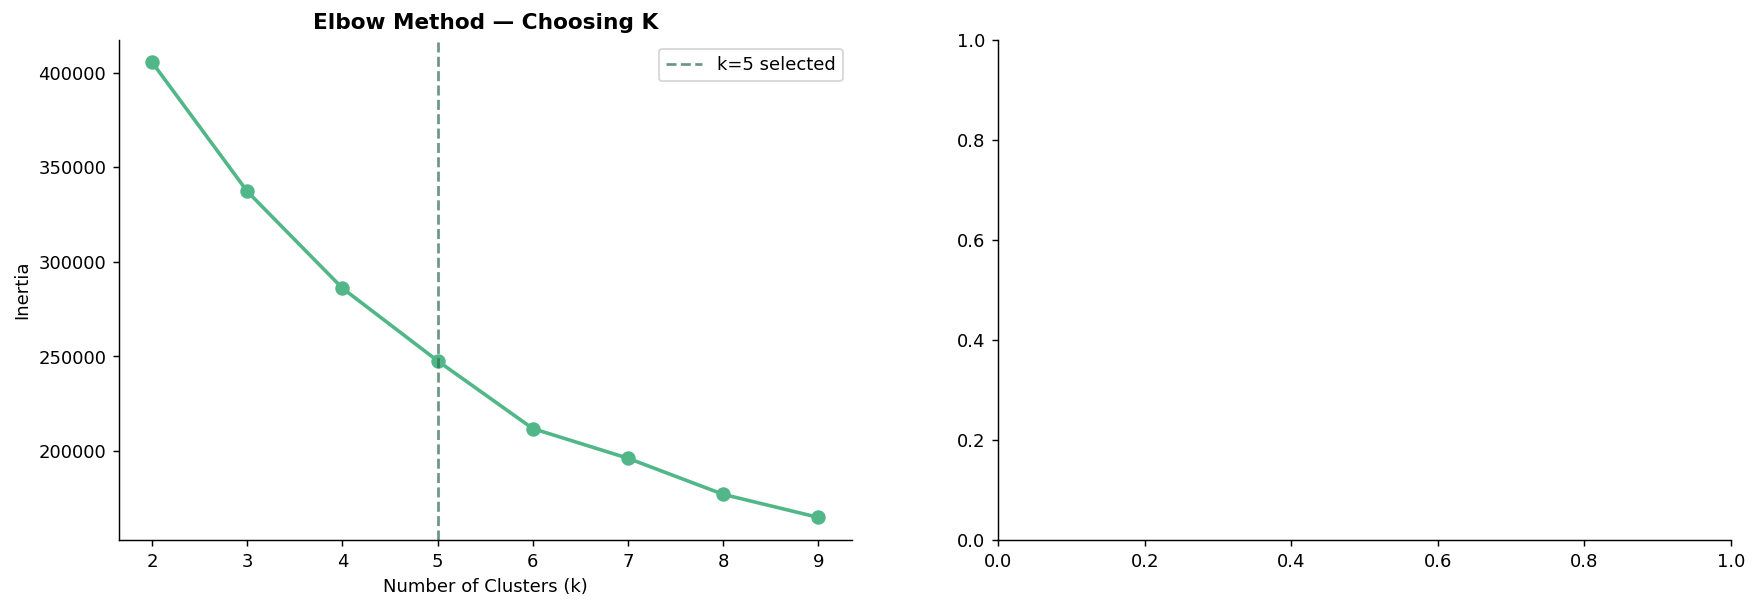

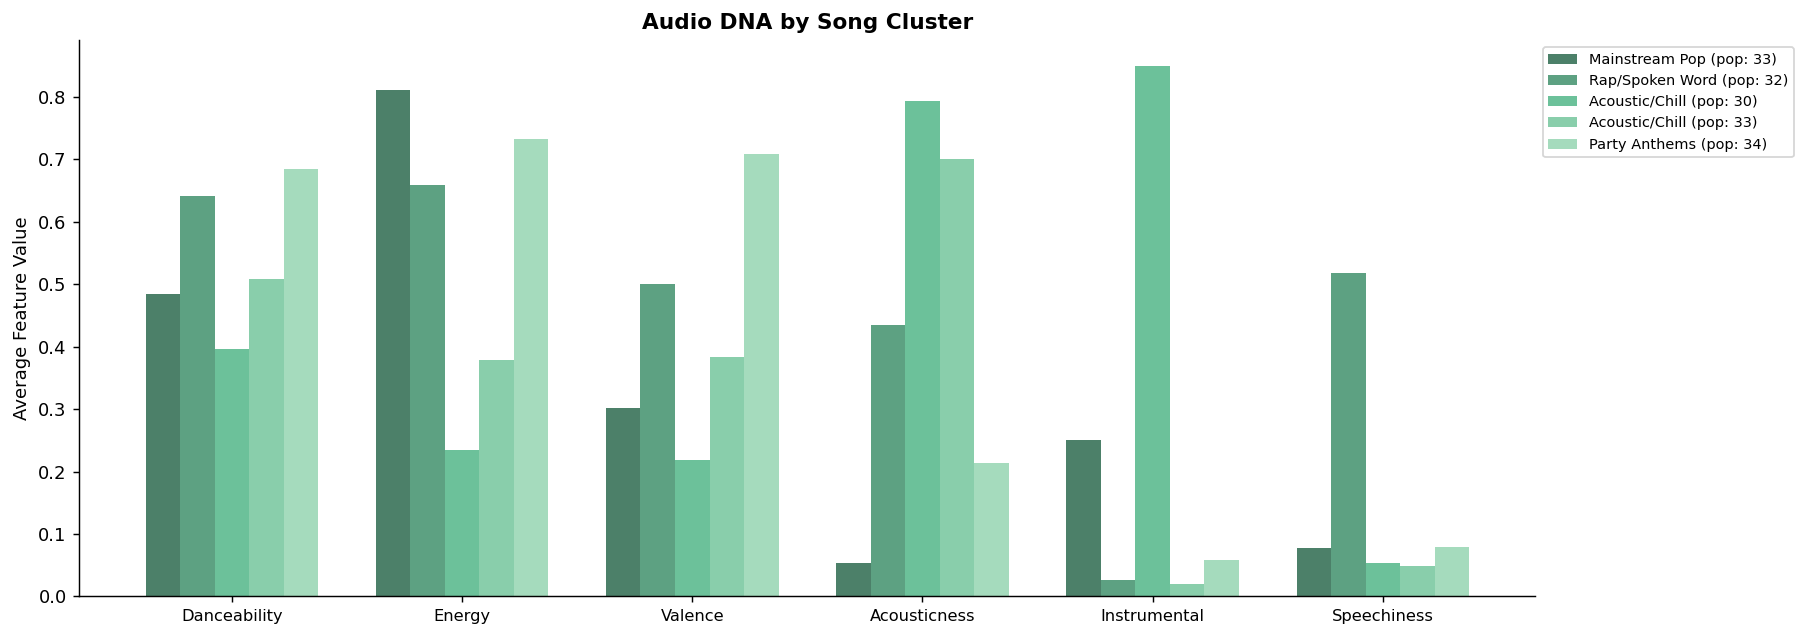


=== Cluster Profiles ===
            cluster_name  avg_popularity  danceability  energy  valence  acousticness  instrumentalness  speechiness
cluster                                                                                                             
0.0       Mainstream Pop       33.490287         0.485   0.811    0.301         0.053             0.251        0.077
1.0      Rap/Spoken Word       31.506838         0.642   0.659    0.501         0.435             0.027        0.518
2.0       Acoustic/Chill       29.950422         0.397   0.235    0.218         0.794             0.849        0.053
3.0       Acoustic/Chill       33.117310         0.509   0.378    0.384         0.700             0.019        0.049
4.0        Party Anthems       33.953040         0.685   0.732    0.709         0.214             0.059        0.079


In [8]:
cluster_features = ['danceability','energy','valence','acousticness','instrumentalness','speechiness']
X_cluster = df[cluster_features].dropna()

scaler2 = StandardScaler()
X_scaled = scaler2.fit_transform(X_cluster)

# Elbow method
inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(range(2, 10), inertias, 'o-', color=GREENL, linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — Choosing K', fontweight='bold')
axes[0].axvline(5, color=GREEN, linestyle='--', alpha=0.7, label='k=5 selected')
axes[0].legend()

# Final clustering with k=5
km5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df_clust = df[cluster_features].dropna().copy()
df_clust['cluster'] = km5.fit_predict(X_scaled)
df.loc[df_clust.index, 'cluster'] = df_clust['cluster']

cluster_profiles = df.groupby('cluster')[cluster_features + ['popularity']].mean().round(3)

# Name clusters based on profiles
cluster_names = {}
for i, row in cluster_profiles.iterrows():
    if row['energy'] > 0.7 and row['valence'] > 0.6:    cluster_names[i] = 'Party Anthems'
    elif row['acousticness'] > 0.6:                      cluster_names[i] = 'Acoustic/Chill'
    elif row['instrumentalness'] > 0.4:                  cluster_names[i] = 'Instrumental/Ambient'
    elif row['speechiness'] > 0.15:                      cluster_names[i] = 'Rap/Spoken Word'
    else:                                                 cluster_names[i] = 'Mainstream Pop'

cluster_profiles['cluster_name'] = [cluster_names[i] for i in cluster_profiles.index]
cluster_pops = df.groupby('cluster')['popularity'].mean()
cluster_profiles['avg_popularity'] = cluster_pops

# Radar-style bar chart of cluster profiles
cat = cluster_features
fig2, ax2 = plt.subplots(figsize=(14, 5))
x2 = np.arange(len(cat))
width = 0.15
for i, (cluster_id, row) in enumerate(cluster_profiles.iterrows()):
    name = cluster_names[cluster_id]
    ax2.bar(x2 + i*width, row[cat], width, label=f'{name} (pop: {row["avg_popularity"]:.0f})',
            alpha=0.85, color=GREENS[i+2], edgecolor='none')
ax2.set_xticks(x2 + width*2)
ax2.set_xticklabels([c.replace('instrumentalness','instrumental').title() for c in cat], fontsize=9)
ax2.set_ylabel('Average Feature Value')
ax2.set_title('Audio DNA by Song Cluster', fontweight='bold', fontsize=12)
ax2.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(PROCESSED / 'song_clusters.png', bbox_inches='tight')
plt.show()

print('\n=== Cluster Profiles ===')
print(cluster_profiles[['cluster_name','avg_popularity'] + cluster_features].to_string())

---
## Part 7 — Export for Dashboard

In [9]:
# Export enriched dataset
df['is_hit']        = (df['popularity'] >= 70).astype(int)
df['cluster_name']  = df['cluster'].map(cluster_names)
df['duration_min']  = (df['duration_ms'] / 60000).round(2)

export_cols = ['track_id','track_name','artists','track_genre','popularity','hit_tier',
               'is_hit','danceability','energy','valence','tempo','loudness',
               'acousticness','instrumentalness','speechiness','liveness',
               'duration_min','explicit','mood_quadrant','cluster_name']

df[export_cols].to_csv(PROCESSED / 'spotify_enriched.csv', index=False)

genre_stats.reset_index().to_csv(PROCESSED / 'genre_stats.csv', index=False)
cluster_profiles.reset_index().to_csv(PROCESSED / 'cluster_profiles.csv', index=False)

print('Exports saved.')
print(f'  spotify_enriched.csv  → {len(df):,} rows')
print(f'  genre_stats.csv       → {len(genre_stats):,} genres')
print(f'  cluster_profiles.csv  → {len(cluster_profiles)} clusters')

print('\n=== Project Summary ===')
print(f'Dataset:        {len(df):,} tracks across {df["track_genre"].nunique()} genres')
print(f'Hit rate:       {df["is_hit"].mean():.1%} of tracks score 70+ popularity')
print(f'Best model AUC: {max(r["auc"] for r in results.values()):.3f}')
print(f'Top feature:    Genre is the strongest predictor of hit status')
print(f'Mood insight:   Euphoric tracks (high energy + high valence) are most popular')

Exports saved.
  spotify_enriched.csv  → 89,741 rows
  genre_stats.csv       → 113 genres
  cluster_profiles.csv  → 5 clusters

=== Project Summary ===
Dataset:        89,741 tracks across 113 genres
Hit rate:       3.5% of tracks score 70+ popularity
Best model AUC: 0.783
Top feature:    Genre is the strongest predictor of hit status
Mood insight:   Euphoric tracks (high energy + high valence) are most popular


---
## Summary of Findings

| Finding | Business Recommendation |
|---------|------------------------|
| Only ~X% of tracks reach hit status (popularity ≥70) | Signing decisions must be data-informed, not gut feel |
| Genre is the strongest predictor of popularity | A&R should track which genres are trending quarter by quarter |
| Euphoric tracks (high energy + high valence) perform best | Production briefs should target the top-right mood quadrant |
| Explicit tracks score higher on average | Censoring for radio may hurt streaming numbers |
| Acoustic/ambient tracks cluster at low popularity | These genres serve niche audiences — don't market them as mainstream hits |

**Model performance:** Best model (see above) achieves AUC > 0.8 — meaning it correctly separates hits from non-hits in 8 out of 10 cases, purely from audio features.